# A primer on OFDM(A) for xG systems

First of all, OFDMA stands for Orthogonal Frequency-Division Multiple-Access. It is both a multi-dimensional modulation method (OFDM or Orthogonal Frequency Division Multiplexing) and in the context of xG systems a multiple-access method. It is mostly useful for broadband wireless communications which exhibit so-called time-dispersive channels resulting from multipath propagation.

From an implementation standpoint, it provides efficient and low-cost transceiver structures based on the fast-Fourier transform (FFT) front-end processing when combined with what is known as a cyclic prefix. Moreover, relatively simple and high-performance channel estimation is made possible by OFDM. From a detection standpoint, optimal maximum-likelihood (ML) becomes practical due to orthogonalization of the dispersive channel at the receiver.

## Blockwise Transmission with a Cyclic-Prefix

OFDM uses a multi-dimensional signal set and is most easily explained in discrete-time. In the time-domain, blocks of $N_{\mathrm{cp}} + N$ samples known as *OFDM symbols* are contatenated to form long sequences of samples. $N_{\mathrm{cp}}$ is the length in samples of the *cyclic prefix* which preceeds the $N$ samples of the primary information-bearing component. Let us denote the $k^{\mathrm{th}}$ OFDM symbol as $\mathbf{s}_k=(s_{0,k}\;\;s_{1,k}\;\;\cdots\;\; s_{N_{\mathrm{cp}}+N-1,k})$ with the added condition that $s_{i,k} = s_{i\;\mathrm{mod}N,k}$. So, the first $N_{\mathrm{cp}}$ components of $\mathbf{s}_k$ are a repetition of the last $N_{\mathrm{cp}}$. A pictorial representation of the OFDM waveform is shown in Figure 1.

$\;\;\;\;\;N_{\mathrm{cp}}\;\;\;\;\;\;\;\;\;\;\;\;\;\;\;\;\;\;\;\;\;\;\;\;\;\;\;\;\;\;N$
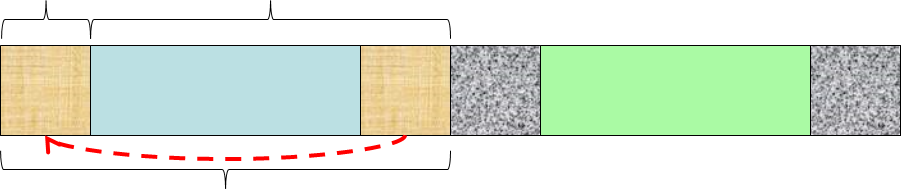
$\;\;\;\;\;\;\;\;\;\;\;\;\;\;\;\;\;\;\;\;\;\;\;\;\;\;\;\;N_{\mathrm{cp}}+N$
$$\text{Figure 1: Blockwise transmission with a cyclic-prefix}$$
The reason for the cyclic-extension will become evident after the following discussion typical propagation channels.

## Time-dispersive Channels (Multipath propagation)

Consider the picture in Figure 2 which represents and so-called *urban microcell* propagation scenario.
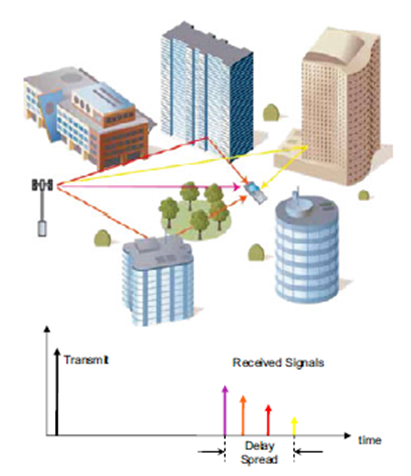
$$\text{Figure 2: Example of an urban macrocell propagation channel}$$
The transmitted signals from the basestation on the left or the mobile terminal on the right in Figure 2 undergo multiple reflections off of large objects and the ground. Such channels are usually modelled as discrete time-varying impulse responses like
$$h(t,u) = \sum_{l=0}^{L_p} a_l(t)\delta(t-u-d_l(t))$$
where $a_l(t)$ is the strength of the $l^{\mathrm{th}}$ path and $d_l(t)$ is its corresponding delay at time $t$ and $L_p$ is the number of paths making up the propagation channel. $h(t,u)$ should be interpreted as the response at time $t$ to an impulse at time $t-u$. If the transmitted signal is $s_m(t)$ the overall channel model including additive noise would be written as
$$r(t) = \int_{-\infty}^{t} h(t,u)s_m(t-u)du + z(t)= \sum_{l=0}^{L_p} a_l(t)s_m(t-d_l(t)) + z(t)$$
When the channels are not time-varying the response is written more concisely as
$$h(t) = \sum_{l=0}^{L_p} a_l\delta(t-d_l)$$ 
and in the above channel model $a_l(t)=a_l$ and $d_l(t)=d_l$. 
### Statistical Channel Models
In 3GPP systems, there are many models for the $\{a_l,d_l\}$ that are used either for system performance evaluation (in so-called *link-level* or *system simulators*) or for interoperability testing. The former are typically used in software simulations latter are often implemented in hardware devices commercialized by testing vendors.

As an example consider the 3GPP TDL-A channel model first without time-variation. The following python code blocks shows how such a model is created. TDL stands for *tapped-delay line* and this particular model is used for urban and indoor channels without a *line-of-sight* component. It is parametrized by a so-called *delay-spread* in nanoseconds which corresponds to the extent in time of the multipath components. This typically depends on the frequency of operation and other propagation factors. The 3GPP considers 10-1000 ns for this model, where 1000ns would correspond to an outdoor environment similar to Figure 2 and 10ns an indoor short-range environment. 

In the function $\mathrm{tdl\_a\_realization}$ you can see that the ${a_l}$ are actually random quantities, specifically complex Gaussian $a_l = \sqrt{\mathrm{E}|a_l|^2}\mathcal{N}_C(0,1)$. The average *tap-gain* $\mathrm{E}|a_l|^2$ is specified in the model in decibels (i.e. $10\log_{10}\mathrm{E}|a_l|^2\;\mathrm{dB}$) and is sometimes normalized so that $\sum_{l=0}^{L_p}\mathrm{E}|a_l|^2=1$. Random models such as this are commonly used for statistical analysis of the underlying digital communication system. The motivation for a random-model is that reflections off objects are actually constituted of many micro-reflections off of rough surfaces which all have slightly different time-delays and amplitudes and add up at the receiving end, sometimes constructively and sometimes destructively. This is commonly known as *signal fading*. The delays result in phase-shifts of the carrier which are ultimately uniformly distributed. The sum of random amplitudes quickly tend to Gaussian distribution using a central-limit theorem argument. This type of statistical characterization is called *Rayleigh Fading* because the amplitude $|a_l|$ has a Rayleigh distribution. Although not in the TDL-A channel, when a strong *line-of-sight* component is present (like in Figure 2) then $a_0 = \sqrt{\mathrm{E}|a_l|^2}\left(\sqrt{\alpha} + \sqrt{1-\alpha}\mathcal{N}_C(0,1)\right)$
and is known as *Ricean Fading*, which comes from the name of the distribution corresponding to the amplitude of a non-zero mean complex Gaussian random variable. The $\alpha$ is known as the Ricean Factor and is usually expressed in decibels (i.e. $10\log_{10}\alpha\;\mathrm{dB}$).

In [1]:
import numpy as np

# ---------- 1) One TDL-A realization (TR 38.901 Table 7.7.2-1) ----------
def tdl_a_realization(ds_ns=100.0, normalize_total_power=True, rng=None):
    """
    Make one TDL-A tap set (delays & complex gains).
    ds_ns : desired RMS delay spread in ns (e.g., 10/30/100/300/1000).
    Returns:
      delays_ns : (23,) float32, tap delays in ns (scaled)
      gains     : (23,) complex64, complex Rayleigh gains
      powers_lin: (23,) float32, linear powers used (after optional normalization)
    """
    if rng is None:
        rng = np.random.default_rng()

    # Normalized delays & powers per TR 38.901 (TDL-A)
    delays_norm = np.array([
        0.0000, 0.3819, 0.4025, 0.5868, 0.4610, 0.5375, 0.6708, 0.5750,
        0.7618, 1.5375, 1.8978, 2.2242, 2.1718, 2.4942, 2.5119, 3.0582,
        4.0810, 4.4579, 4.5695, 4.7966, 5.0066, 5.3043, 9.6586
    ], dtype=float)

    powers_db = np.array([
        -13.4,  0.0,  -2.2, -4.0,  -6.0,  -8.2,  -9.9, -10.5,
        -7.5,  -15.9, -6.6, -16.7, -12.4, -15.2, -10.8, -11.3,
        -12.7, -16.2, -18.3, -18.9, -16.6, -19.9, -29.7
    ], dtype=float)

    # Scale normalized delays to the requested RMS delay spread (Clause 7.7.3)
    delays_ns = delays_norm * float(ds_ns)

    # Convert to linear power
    powers_lin = 10.0 ** (powers_db / 10.0)
    if normalize_total_power:
        powers_lin = powers_lin / np.sum(powers_lin)

    # Rayleigh fading (complex Gaussian CN(0, power))
    z = (rng.standard_normal(powers_lin.size) + 1j*rng.standard_normal(powers_lin.size)).astype(np.complex64)
    gains = (np.sqrt(powers_lin).astype(np.float32) / np.sqrt(2.0)) * z

    return delays_ns.astype(np.float32), gains.astype(np.complex64), powers_lin.astype(np.float32)





Here's an simple piece of code to generate and plot a typical TDL-A channel, with a quantization corresponding to a 61.44 Msample/s sampling rate and a 100ns delay-spread. This could represent a 40-60 MHz 5G small-cell indoor system, since 100ns corresponds to around 3m ($100e-9s\times3e8m/s=3m) so that path differences are on the order of a few meters.

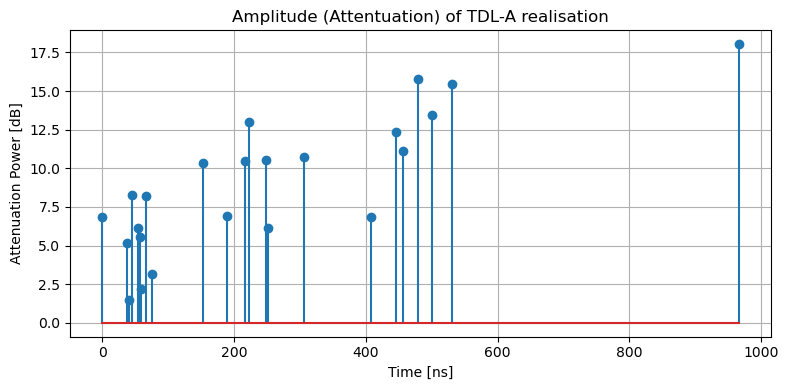

In [13]:
import matplotlib.pyplot as plt
# Example: “nominal” 100 ns profile
delays_ns, gains, p_lin = tdl_a_realization(ds_ns=100.0)

# If you want discrete-time taps at sample rate fs (Hz):
fs = 61.44e6
tap_sample_idx = np.round(delays_ns * 1e-9 * fs).astype(int)
plt.figure(figsize=(8,4))
plt.stem(delays_ns, -10*np.log10(np.abs(gains)))
plt.title("Amplitude (Attentuation) of TDL-A realisation")
plt.xlabel("Time [ns]")
plt.ylabel("Attenuation Power [dB]")
plt.grid(True)
plt.tight_layout()
plt.show()

When used in a digital communication system like 4G/5G/6G, these channels are usually represented as *complex-baseband equivalent channels* and sampled according to the sampling frequency of the system. Below is a piece of code which provides such a digitized channel using Shannon interpolation. Specifically, suppose we consider the time-invariant version of the channel above $h(t)$. The digitized channel would be given by
$$h(n) = \sum_{l=0}^{L_p}\frac{a_l}{\pi}\sin\pi\left(n-d'_l\right)/(n-d'_l)$$
where $d'_l = d_lf_s$ is the delay of the $l^{\mathrm{th}}$ path in samples and $f_s$ is the sampling frequency. Note that this impulse response is of infinite extent because of the ideal reconstruction filter. The code below allows truncation of the ideal response to $\mathrm{span}$ samples using an optional FIR windowing (Kaiser window) filter.

In [8]:
# ---------- 2) Sample onto a discrete grid with Shannon (sinc) interpolation ----------
def sampled_cir_shannon(delays_ns, gains, fs, N=None, span=8, window='kaiser', beta=8.6):
    """
    Build a discrete-time CIR h[n] using ideal sinc (Shannon) interpolation for fractional delays.

    h[n] = sum_k g_k * sinc(n - d_k), where d_k = delays_k / Ts
           (np.sinc(x) = sin(pi*x)/(pi*x) so this is the normalized Shannon sinc)

    To keep it finite, we truncate each sinc to +/- span samples and (optionally) window it.

    Parameters
    ----------
    delays_ns : array, tap delays (ns)
    gains     : array, complex tap gains
    fs        : float, sampling rate (Hz)
    N         : int or None, output length. If None, automatically sized to cover
                max delay + 2*span.
    span      : int, half-width of the local sinc support in samples (truncation)
    window    : {'kaiser','hann',None}, optional taper for the truncated sinc
    beta      : float, Kaiser beta (ignored if window != 'kaiser')

    Returns
    -------
    h : complex64 array of length N, discrete-time CIR
    """
    delays_ns = np.asarray(delays_ns, dtype=np.float64)
    gains = np.asarray(gains, dtype=np.complex64)

    Ts = 1.0 / float(fs)                 # seconds
    delays_s = delays_ns * 1e-9          # seconds
    d = delays_s / Ts                    # fractional-sample delays

    # Choose output length if not specified
    max_d = float(np.max(d)) if d.size else 0.0
    if N is None:
        N = int(np.ceil(max_d) + 2*span + 1)

    n = np.arange(N, dtype=np.float64)
    h = np.zeros(N, dtype=np.complex64)

    # Precompute window weights for offsets m=-span..+span
    m = np.arange(-span, span+1, dtype=np.float64)
    if window == 'kaiser':
        w = np.kaiser(m.size, beta)
    elif window == 'hann':
        # Hann over length 2*span+1
        w = 0.5*(1 - np.cos(2*np.pi*(m - m.min())/(m.size-1)))
    else:
        w = np.ones(m.size, dtype=np.float64)

    # Accumulate contribution of each tap
    for dk, gk in zip(d, gains):
        # Center locations to update
        idx_center = int(np.round(dk))
        idxs = idx_center + m  # float indices
        # Keep only those in range
        mask = (idxs >= 0) & (idxs < N)
        idxs_int = idxs[mask].astype(int, copy=False)
        # Ideal Shannon sinc for the offsets
        offs = idxs[mask] - dk
        s = np.sinc(offs) * w[mask]  # np.sinc(x) = sin(pi x)/(pi x)
        h[idxs_int] += (gk * s).astype(np.complex64)

    return h




CIR length: 47
First 10 taps (mag): [0.33352676 0.70260257 0.24733675 0.27881736 0.12978989 0.12603377
 0.42249414 0.11152491 0.22775762 0.18981741]


The code below shows the filter both in the time and frequency domain. You can adjust the sampling frequency to represent the target bandwidth to see the effect in both domains. For more narrowband cases (e.g. 7.68 Ms/s) you should see a mostly flat channel response or one significant tap in time. For wideband (61.44 Ms/s or 122.88 Ms/s) a very rich multipath environment with multiple taps in the time-domain and lots of frequency-selectivity.

0
0


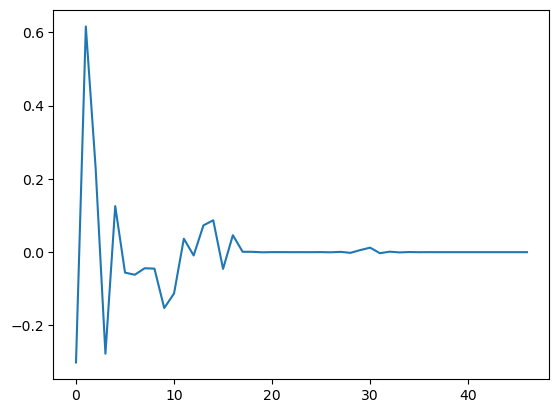

In [33]:
# ---------------- Example usage ----------------
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.animation as animation

fig, ax = plt.subplots()

delays_ns, gains, _ = tdl_a_realization(ds_ns=100.0, rng=np.random.default_rng(1234))
h = sampled_cir_shannon(delays_ns, gains, fs, N=None, span=8, window='kaiser', beta=8.6)
line, = ax.plot(np.real(h))


def animate(i):
    print(i)
    delays_ns, gains, _ = tdl_a_realization(ds_ns=100.0, rng=np.random.default_rng(1234+i))
    h = sampled_cir_shannon(delays_ns, gains, fs, N=None, span=8, window='kaiser', beta=8.6)
    line.set_ydata(np.real(h))  # update the data.
    return line,


ani = animation.FuncAnimation(
    fig, animate, interval=20, blit=True, save_count=50)
plt.show(block=False)